# Homework 2 CSCI E-82 2026
 
## Updated 9/19/2026


### Your name:

In [40]:
# Ayoola Njoku

### Which one of the 4 options did you take:
* Novice, 
* Experienced, 
* Experienced seeking a challenge 
* Experienced seeking a challenge at scale

**Please delete all the other options from your notebook**

In [41]:
# Novice

# Due Saturday October 3, 2026 11:59 pm EST

### This is an individual homework.

### Show your work (i.e., code) and provide brief explanations where appropriate.  Include both your notebook file and a pdf file.  If you have leveraged any resources, be sure to include their citation where they are used

### We do like to see your work and the outputs.  However, we don't need very chatty output since it makes it difficult to find your answer. That means if you run 10K epochs, we don't need a 70 page pdf file.

### Note:  we want you to build your own networks throughout this homework.  This means defining each of the layers in the networks rather than use any pre-built classifiers that come with various platforms.


### We have created 4 different homework assignments for this assignment.  You are welcome and encouraged to try all of them, but tell us which one you want graded.  We also have a default medium-sized data set and a scaled down one in case everything fails and you're running it on your laptop on Oct 2 morning.  We might give a few extra points if you do something else that is awesome.  

### The intention is that if this is your first CNN, there is a lot of new concepts and ideas to get through so try the Problem Set for CNN Novices.  To go further, consider a transfer learning approach.

### If you've tried CNNs before as the majority have, we encourage you to try something more interesting.  If you are beginner, you can and should try both to maximize learning.  If you are already experienced in CNNs from your own work or other classes, you may submit the simpler version and avoid learning anything new.   To go further, consider a transfer learning approach.

### For those seeking a challenge, we have a real data set with an interesting challenge. 



## FAQ

### Will we give extra credit if you try all of them?  No

### Can I earn more points for trying the more challenging problems?  No

### If I'm a CNN novice, can I try one of the harder problems instead?  Sure

### I have CNN experience but don't want to learn anything.  Can I just do the simplest case?  I can't stop you, but I'm not sure why you're taking the class.

### Can we use our own PC or Google Colab?  Yes

# <span style="color:blue">Option 1 Problem Set for CNN novices</span>

### The goal of this assignment is to classify 3 different types of images:  abstract, portraits and landscapes.  To standardize things, we have divided the data into training, validation and test sets.   Train on the training and assess whether you are overfitting based on the validation.  You can ignore the test set until the last problem where we ask you to make predictions on each image.  

### The labels for the images are not in the filename but in the truth.txt file.  There is a column called "TrainValidateTest" which specifies the train/validate/test for the data.

## Problem 1 Baseline Feedforward neural network classifier -- 10 points

### Use the training images to train up a feedforward classifier using the provided truth.txt file which has the image names and labels.  

### Use the validation images to assess the performance of the classifier using the associated image names and labels.

### Create a plot of the training and validation results as a function of the epoch.  If you are using different metrics, be sure to put them on different plots.

GPU is not available; using CPU.
X_train shape: torch.Size([31991, 3, 50, 50])
y_train shape: torch.Size([31991])
X_val shape: torch.Size([6000, 3, 50, 50])
y_val shape: torch.Size([6000])
X_test shape: torch.Size([4882, 3, 50, 50])
y_test shape: torch.Size([4882])
Epoch 1/10, Train Loss: 0.9652, Train Acc: 0.5202, Val Loss: 0.8936, Val Acc: 0.5967
Epoch 2/10, Train Loss: 0.8967, Train Acc: 0.5623, Val Loss: 0.8706, Val Acc: 0.6078
Epoch 3/10, Train Loss: 0.8830, Train Acc: 0.5695, Val Loss: 0.8534, Val Acc: 0.6313
Epoch 4/10, Train Loss: 0.8692, Train Acc: 0.5780, Val Loss: 0.8594, Val Acc: 0.5963
Epoch 5/10, Train Loss: 0.8581, Train Acc: 0.5890, Val Loss: 0.8510, Val Acc: 0.6160
Epoch 6/10, Train Loss: 0.8549, Train Acc: 0.5918, Val Loss: 0.8396, Val Acc: 0.6208
Epoch 7/10, Train Loss: 0.8488, Train Acc: 0.5986, Val Loss: 0.8167, Val Acc: 0.6257
Epoch 8/10, Train Loss: 0.8462, Train Acc: 0.5982, Val Loss: 0.8555, Val Acc: 0.6175
Epoch 9/10, Train Loss: 0.8428, Train Acc: 0.6024, Val

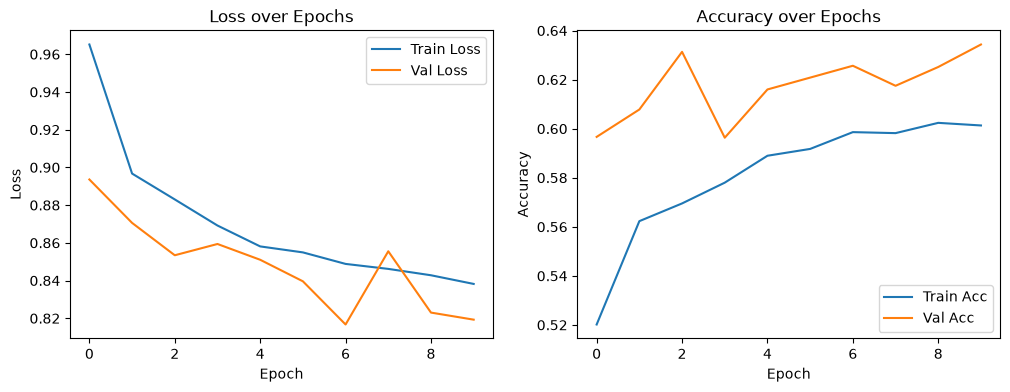

In [42]:
import torch 
import torch.nn as nn
import numpy as np
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset, TensorDataset
import os
from PIL import Image

if torch.cuda.is_available():
    print("GPU is available.")
    print("GPU device name:", torch.cuda.get_device_name(0))
    print("Number of GPUs:", torch.cuda.device_count())
else:
    print("GPU is not available; using CPU.")



class MyModel(nn.Module):
    def __init__(self):
        super(MyModel, self).__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(3*50*50, 512),
            nn.ReLU(),
            nn.Dropout(0.5),  # Add dropout for regularization
            nn.Linear( 512,128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 3),
        )
        

    def forward(self, x):
        return self.net(x)
root = "50x50/"
splits = {
    "train": ([], []),
    "validate": ([], []),
    "test": ([], [])
}
class_to_idx = {
    "portrait": 0,
    "landscape": 1,
    "abstract": 2
}


with open("truth.txt", "r") as f:
    next(f)  # Skip the header line
    for line in f:
        filename, split, style, genre, artist = line.rstrip().split("\t")
        # since we've been asked for 3 classes, I've merged "self-portrait" into "portrait"
        if style == "self-portrait":
            style = "portrait"
        path = os.path.join(root, split, filename)
        if not os.path.exists(path):
            continue
        img = Image.open(path).convert("RGB")
        if not img:
            continue
        splits[split][0].append(img)
        splits[split][1].append(class_to_idx[style])


def toTensor(img, labels):
    img = np.stack(img, axis=0)  # Stack images along a new dimension
    img = torch.tensor(img, dtype=torch.float32).permute(0, 3, 1, 2) / 255.0  # Normalize to [0, 1]
    labels = torch.tensor(labels, dtype=torch.long)
    return img, labels

X_train, y_train = toTensor(*splits["train"])
X_val,   y_val   = toTensor(*splits["validate"])
X_test,  y_test  = toTensor(*splits["test"]) 


print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

train_dataset = DataLoader(TensorDataset(X_train, y_train), batch_size=32, shuffle=True)
val_dataset = DataLoader(TensorDataset(X_val, y_val), batch_size=32, shuffle=False)
test_dataset = DataLoader(TensorDataset(X_test, y_test), batch_size=32, shuffle=False)

import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "mps"
model = MyModel().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

num_epochs = 10

def run_epoch(model, dataloader, criterion, optimizer, device, train=True):
    model.train(train)
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.set_grad_enabled(model.training):
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

for epoch in range(num_epochs):
    train_loss, train_acc = run_epoch(model, train_dataset, criterion, optimizer, device, train=True)
    val_loss, val_acc = run_epoch(model, val_dataset, criterion, optimizer, device, train=False)
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

# Plot training and validation loss
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Loss over Epochs")

# Plot training and validation accuracy
plt.subplot(1, 2, 2)
plt.plot(history["train_acc"], label="Train Acc")
plt.plot(history["val_acc"], label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Accuracy over Epochs")

plt.show()

## Problem 2 Baseline CNN classifier -- 10 points

### Use the training images to train up a CNN classifier using the provided truth.txt file which has the image names and labels.  

### Use the validation images to assess the performance of the classifier using the associated image names and labels.

### Create a plot of the training and validation results as a function of the epoch.


Number of Parameters in CNN Model: 319,011
Model Architecture:

landscapeAbstractPortraitCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=2304, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=3, bias=True)
)
Epoch 1/20, Train Loss: 0.7139, Train Acc: 0.6883, Val Loss: 0.5990, Val Acc: 0.7557
Epoch 2/20, Train Loss: 0.5754, Train Acc: 0.7623, Val Loss: 0.5464, Val Acc: 0.7775
Epoch 3/20, Train Loss: 0.5209, Train Acc: 0.7884, Val Loss: 0.5138, Val Acc: 0.7965
Epoch 4/20, Train Loss: 0.4889, Train Acc: 0.8057, Val Loss: 0.4851, Val Acc: 0.8082
Epoch 5/20, Train Loss: 0.4617, Train Acc: 0.8144, Val Loss: 0.4852, Val Acc: 0.811

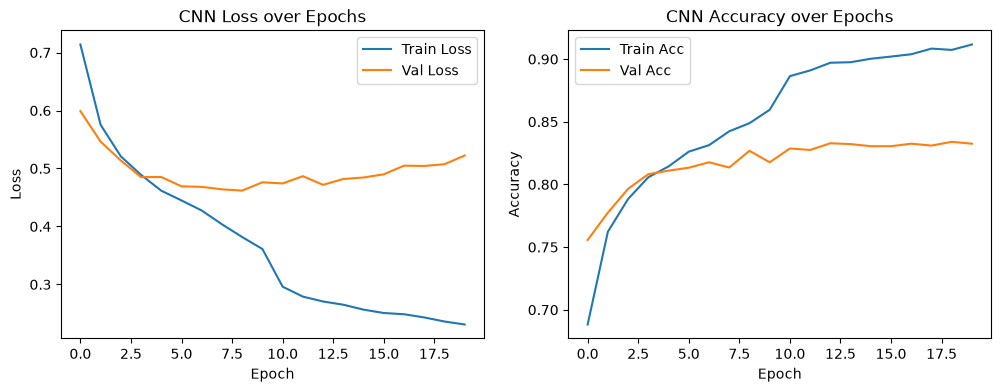

In [43]:
import torch.nn.functional as F

class landscapeAbstractPortraitCNN(nn.Module):
    def __init__(self, kernel_size=3, hidden_size=128, dropout=0.5):
            super(landscapeAbstractPortraitCNN, self).__init__()
            padding = kernel_size // 2 # adjusting padding to round the kernel size to maintain spatial dimensions
            # explanation of the first channel 
            # hese 16 channels extract low-level, primitive features directly from the raw pixels. 
            # They map out basic visual building blocks like horizontal edges, vertical borders, color gradients, and simple textures.
            self.conv1 = nn.Conv2d(3, 16, kernel_size = kernel_size, padding = padding)
            # explanation of the second channel
            # These 32 channels extract mid-level features.
            #  By combining the basic lines and edges from the first layer, 
            # they start to recognize geometric shapes, corners, grids, or simple patterns (e.g., circles, crosses, or specific fabric textures).
            self.conv2 = nn.Conv2d(16, 32, kernel_size = kernel_size, padding = padding)
            # explanation of the third channel
            # These 64 channels extract high-level, abstract features. 
            # By combining shapes and patterns from the second layer, these channels begin to recognize complex parts of actual objects
            #  (e.g., a wheel, a dog's ear, a text character, or a window pane).
            self.conv3 = nn.Conv2d(32, 64, kernel_size = kernel_size, padding = padding)
            self.pool = nn.MaxPool2d(2)
            self.dropout = nn.Dropout(dropout)
            self.fc1 = nn.Linear(64 * 6 * 6, hidden_size) 
            self.fc2 = nn.Linear(hidden_size, 3)
            
    
    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = x.view(x.size(0), -1)          # flatten -> (batch, 2304)
        x = self.dropout(F.relu(self.fc1(x)))
        return self.fc2(x)                 # raw logits for CrossEntropyLoss


cnn_model = landscapeAbstractPortraitCNN().to(device)

total_params = sum([p.numel() for p in cnn_model.parameters()])
print(f"Number of Parameters in CNN Model: {total_params:,}")
print("Model Architecture:\n")
print(cnn_model)
print("===" * 20)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(cnn_model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

num_epochs = 20

cnn_history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

for epoch in range(num_epochs):
     train_loss, train_acc = run_epoch(cnn_model, train_dataset, loss_fn, optimizer, device)
     val_loss, val_acc = run_epoch(cnn_model, val_dataset, loss_fn, optimizer, device,train=False)
     cnn_history["train_loss"].append(train_loss)
     cnn_history["train_acc"].append(train_acc)
     cnn_history["val_loss"].append(val_loss)
     cnn_history["val_acc"].append(val_acc)
     scheduler.step()
     print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

# Plot CNN training and validation loss
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(cnn_history["train_loss"], label="Train Loss")
plt.plot(cnn_history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("CNN Loss over Epochs")

plt.subplot(1, 2, 2)
plt.plot(cnn_history["train_acc"], label="Train Acc")
plt.plot(cnn_history["val_acc"], label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("CNN Accuracy over Epochs")

plt.show()

## Problem 3  Improved CNN classifier -- 15 points

### Chose a single parameter with at least 3 different values and optimize over that parameter.  The parameter could be the number or size of the convolutional kernels, the number/size of the layers.  Report the performance as a function of epoch for each version and select the best. 

Kernel size 3x3
Epoch 1/20, Train Loss: 0.7112, Train Acc: 0.6872, Val Loss: 0.6390, Val Acc: 0.7203
Epoch 2/20, Train Loss: 0.5809, Train Acc: 0.7589, Val Loss: 0.5869, Val Acc: 0.7515
Epoch 3/20, Train Loss: 0.5298, Train Acc: 0.7846, Val Loss: 0.5409, Val Acc: 0.7767
Epoch 4/20, Train Loss: 0.4951, Train Acc: 0.8006, Val Loss: 0.4944, Val Acc: 0.8002
Epoch 5/20, Train Loss: 0.4653, Train Acc: 0.8152, Val Loss: 0.5103, Val Acc: 0.7947
Epoch 6/20, Train Loss: 0.4439, Train Acc: 0.8240, Val Loss: 0.4813, Val Acc: 0.8103
Epoch 7/20, Train Loss: 0.4251, Train Acc: 0.8307, Val Loss: 0.4741, Val Acc: 0.8143
Epoch 8/20, Train Loss: 0.4051, Train Acc: 0.8408, Val Loss: 0.4768, Val Acc: 0.8168
Epoch 9/20, Train Loss: 0.3844, Train Acc: 0.8467, Val Loss: 0.5149, Val Acc: 0.8088
Epoch 10/20, Train Loss: 0.3651, Train Acc: 0.8541, Val Loss: 0.5347, Val Acc: 0.8067
Epoch 11/20, Train Loss: 0.3007, Train Acc: 0.8822, Val Loss: 0.4927, Val Acc: 0.8237
Epoch 12/20, Train Loss: 0.2883, Train Acc: 0.8

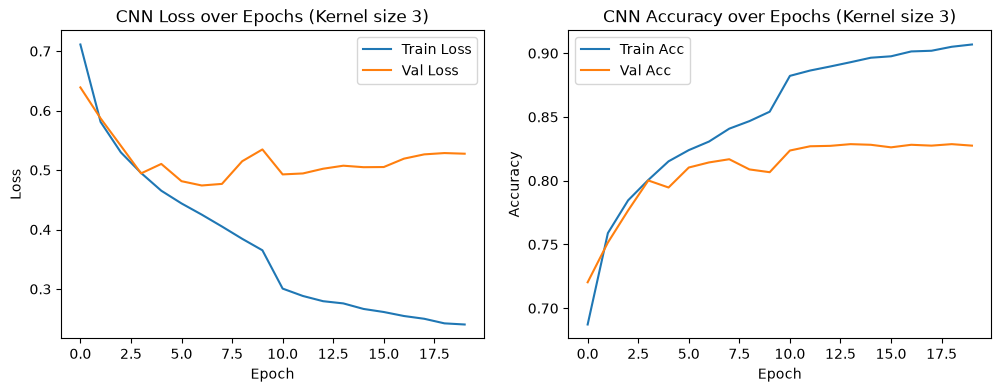

Finished training with kernel size 3
Kernel size 5x5
Epoch 1/20, Train Loss: 0.7108, Train Acc: 0.6936, Val Loss: 0.5840, Val Acc: 0.7583
Epoch 2/20, Train Loss: 0.5710, Train Acc: 0.7672, Val Loss: 0.5582, Val Acc: 0.7772
Epoch 3/20, Train Loss: 0.5181, Train Acc: 0.7941, Val Loss: 0.5869, Val Acc: 0.7678
Epoch 4/20, Train Loss: 0.4808, Train Acc: 0.8084, Val Loss: 0.5566, Val Acc: 0.7687
Epoch 5/20, Train Loss: 0.4573, Train Acc: 0.8175, Val Loss: 0.5041, Val Acc: 0.8032
Epoch 6/20, Train Loss: 0.4306, Train Acc: 0.8314, Val Loss: 0.4986, Val Acc: 0.8067
Epoch 7/20, Train Loss: 0.4020, Train Acc: 0.8417, Val Loss: 0.4988, Val Acc: 0.8057
Epoch 8/20, Train Loss: 0.3710, Train Acc: 0.8539, Val Loss: 0.5361, Val Acc: 0.8052
Epoch 9/20, Train Loss: 0.3445, Train Acc: 0.8639, Val Loss: 0.5160, Val Acc: 0.8128
Epoch 10/20, Train Loss: 0.3167, Train Acc: 0.8751, Val Loss: 0.5506, Val Acc: 0.8075
Epoch 11/20, Train Loss: 0.2322, Train Acc: 0.9105, Val Loss: 0.5954, Val Acc: 0.8143
Epoch 12/2

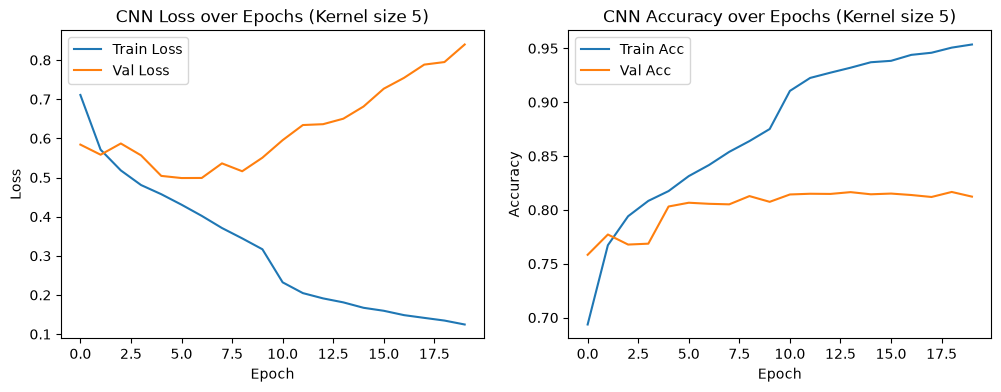

Finished training with kernel size 5
Kernel size 7x7
Epoch 1/20, Train Loss: 0.7483, Train Acc: 0.6701, Val Loss: 0.6562, Val Acc: 0.7125
Epoch 2/20, Train Loss: 0.6009, Train Acc: 0.7481, Val Loss: 0.5907, Val Acc: 0.7528
Epoch 3/20, Train Loss: 0.5516, Train Acc: 0.7753, Val Loss: 0.5834, Val Acc: 0.7670
Epoch 4/20, Train Loss: 0.5131, Train Acc: 0.7910, Val Loss: 0.5310, Val Acc: 0.7852
Epoch 5/20, Train Loss: 0.4798, Train Acc: 0.8078, Val Loss: 0.5224, Val Acc: 0.7968
Epoch 6/20, Train Loss: 0.4492, Train Acc: 0.8210, Val Loss: 0.5236, Val Acc: 0.7873
Epoch 7/20, Train Loss: 0.4141, Train Acc: 0.8341, Val Loss: 0.5325, Val Acc: 0.7965
Epoch 8/20, Train Loss: 0.3828, Train Acc: 0.8457, Val Loss: 0.5323, Val Acc: 0.8057
Epoch 9/20, Train Loss: 0.3531, Train Acc: 0.8583, Val Loss: 0.5813, Val Acc: 0.8002
Epoch 10/20, Train Loss: 0.3146, Train Acc: 0.8753, Val Loss: 0.6525, Val Acc: 0.7943
Epoch 11/20, Train Loss: 0.2171, Train Acc: 0.9155, Val Loss: 0.6963, Val Acc: 0.8005
Epoch 12/2

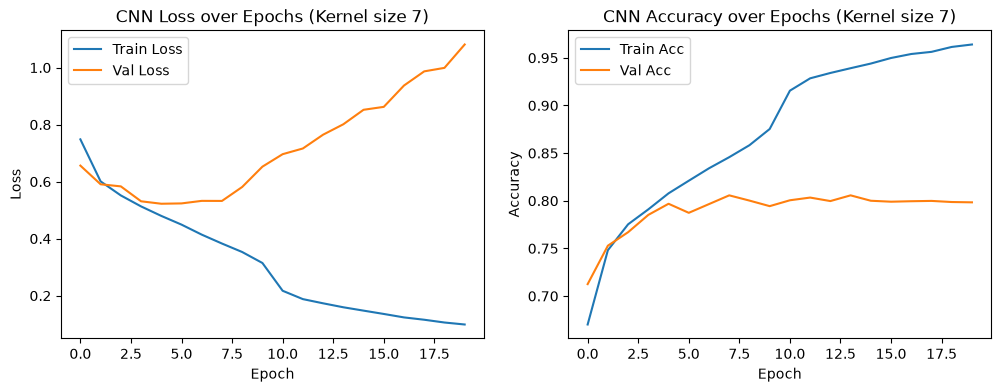

Finished training with kernel size 7
Kernel size 9x9
Epoch 1/20, Train Loss: 0.7644, Train Acc: 0.6601, Val Loss: 0.6589, Val Acc: 0.7130
Epoch 2/20, Train Loss: 0.6342, Train Acc: 0.7305, Val Loss: 0.6004, Val Acc: 0.7437
Epoch 3/20, Train Loss: 0.5734, Train Acc: 0.7637, Val Loss: 0.5683, Val Acc: 0.7615
Epoch 4/20, Train Loss: 0.5360, Train Acc: 0.7788, Val Loss: 0.5363, Val Acc: 0.7808
Epoch 5/20, Train Loss: 0.5001, Train Acc: 0.7943, Val Loss: 0.5555, Val Acc: 0.7823
Epoch 6/20, Train Loss: 0.4777, Train Acc: 0.8057, Val Loss: 0.5552, Val Acc: 0.7835
Epoch 7/20, Train Loss: 0.4362, Train Acc: 0.8226, Val Loss: 0.5527, Val Acc: 0.7790
Epoch 8/20, Train Loss: 0.4025, Train Acc: 0.8395, Val Loss: 0.6280, Val Acc: 0.7753
Epoch 9/20, Train Loss: 0.3690, Train Acc: 0.8536, Val Loss: 0.6242, Val Acc: 0.7810
Epoch 10/20, Train Loss: 0.3326, Train Acc: 0.8687, Val Loss: 0.6598, Val Acc: 0.7770
Epoch 11/20, Train Loss: 0.2221, Train Acc: 0.9149, Val Loss: 0.7305, Val Acc: 0.7868
Epoch 12/2

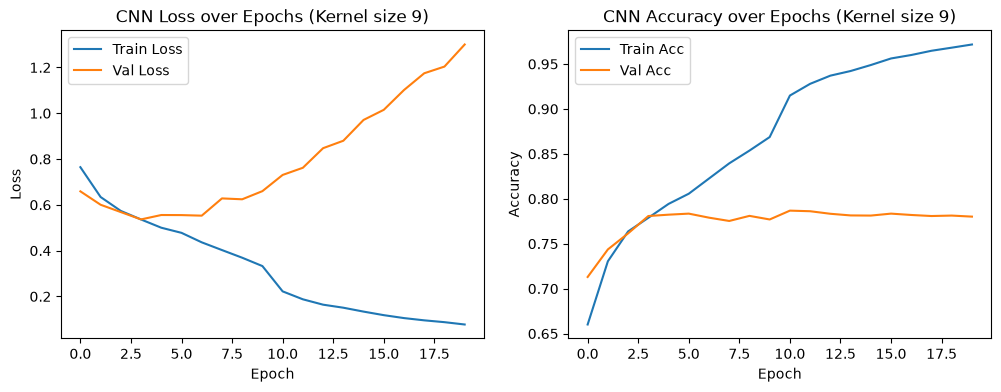

Finished training with kernel size 9
Best validation accuracy: 0.8287 with kernel size 3


In [44]:

import copy # for copying model evaluation parameters

kernel_sizes = [3, 5, 7, 9]
best_vals= {"val_acc": 0, "kernel_size": None, "state_dict": None}




for k in kernel_sizes:
    print(f"Kernel size {k}x{k}")
    torch.manual_seed(42)
    cnn_model = landscapeAbstractPortraitCNN(kernel_size=k).to(device)
    optimizer = torch.optim.Adam(cnn_model.parameters(), lr=0.001)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)
    cnn_history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    for epoch in range(num_epochs):
        train_loss, train_acc = run_epoch(cnn_model, train_dataset, loss_fn, optimizer, device)
        val_loss, val_acc = run_epoch(cnn_model, val_dataset, loss_fn, optimizer, device,train=False)
        if val_acc > best_vals["val_acc"]: # Keeping track of the best validation accuracy and corresponding model state in order to figure out what kernel to use for question 4
            best_vals["val_acc"] = val_acc
            best_vals["kernel_size"] = k
            best_vals["state_dict"] = copy.deepcopy(cnn_model.state_dict())
        cnn_history["train_loss"].append(train_loss)
        cnn_history["train_acc"].append(train_acc)
        cnn_history["val_loss"].append(val_loss)
        cnn_history["val_acc"].append(val_acc)
        scheduler.step()
        print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")
    print(f"Training history for kernel size {k}:")
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(cnn_history["train_loss"], label="Train Loss")
    plt.plot(cnn_history["val_loss"], label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.title(f"CNN Loss over Epochs (Kernel size {k})")

    plt.subplot(1, 2, 2)
    plt.plot(cnn_history["train_acc"], label="Train Acc")
    plt.plot(cnn_history["val_acc"], label="Val Acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.title(f"CNN Accuracy over Epochs (Kernel size {k})")

    plt.show()
    print(f"Finished training with kernel size {k}")
    cnn_history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }
print(f"Best validation accuracy: {best_vals['val_acc']:.4f} with kernel size {best_vals['kernel_size']}")
torch.save(best_vals["state_dict"], f"best_model_kernel_{best_vals['kernel_size']}.pth") # this is incase the process crashes and we want to reload the best model later

## Problem 4 Optimized CNN classifier -- 15 points

### Problem 3 was the optimization of just one parameter. Use that model to fully optimize the classifier to achieve the best results that you can.  Create a plot of the training and validation results as a function of the epoch.  Which combination of parameters gave the best results?



lr=0.001, hidden=128, dropout=0.5: best val acc 0.8168
lr=0.0001, hidden=128, dropout=0.5: best val acc 0.7780
lr=0.01, hidden=128, dropout=0.5: best val acc 0.6737
lr=0.001, hidden=64, dropout=0.5: best val acc 0.8138
lr=0.001, hidden=256, dropout=0.5: best val acc 0.8205
lr=0.001, hidden=256, dropout=0.3: best val acc 0.8232

Best config: lr=0.001, hidden=256, dropout=0.3, kernel=3, val acc 0.8232


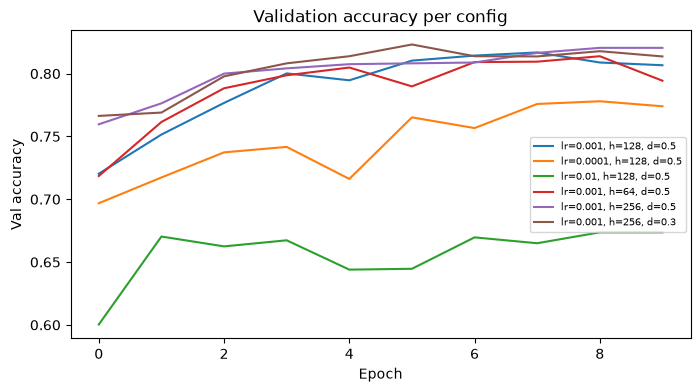

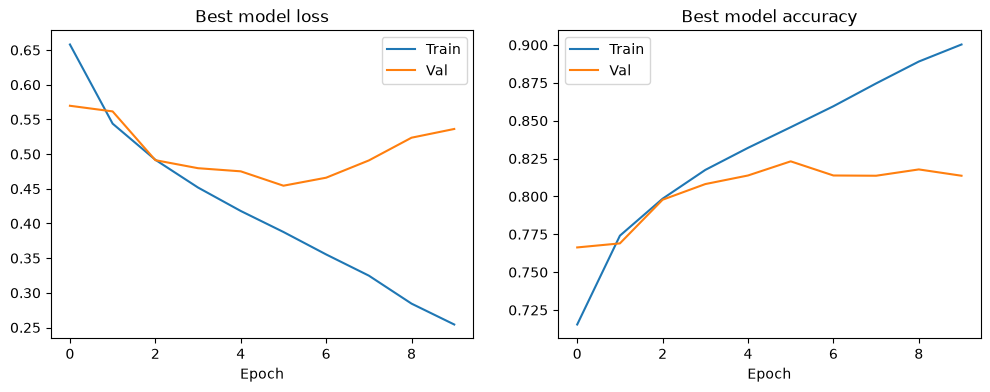

In [45]:
best_kernel_size = best_vals["kernel_size"]

def train_config(lr, hidden_size=128, dropout=0.5, num_epochs=10):
    torch.manual_seed(42)
    m = landscapeAbstractPortraitCNN(kernel_size=best_kernel_size,
                                     hidden_size=hidden_size, dropout=dropout).to(device)
    opt = torch.optim.Adam(m.parameters(), lr=lr)
    hist = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    best_acc, best_state = 0.0, None
    for epoch in range(num_epochs):
        tl, ta = run_epoch(m, train_dataset, loss_fn, opt, device, train=True)
        vl, va = run_epoch(m, val_dataset, loss_fn, opt, device, train=False)
        for key, v in zip(["train_loss", "train_acc", "val_loss", "val_acc"], [tl, ta, vl, va]):
            hist[key].append(v)
        if va > best_acc:
            best_acc, best_state = va, copy.deepcopy(m.state_dict())
    return {"hist": hist, "best_acc": best_acc, "state": best_state}

runs = {}   # (lr, hidden_size, dropout) -> result

def run(lr, hs=128, do=0.5):
    key = (lr, hs, do)
    if key not in runs:                      # don't retrain a config we already ran
        runs[key] = train_config(lr, hs, do)
        print(f"lr={lr}, hidden={hs}, dropout={do}: best val acc {runs[key]['best_acc']:.4f}")
    return runs[key]

# Step 1: learning rate (hidden=128, dropout=0.5)
for lr in [0.001, 0.0001, 0.01]:
    run(lr)
best_lr = max([0.001, 0.0001, 0.01], key=lambda lr: runs[(lr, 128, 0.5)]["best_acc"])

# Step 2: hidden size at the best lr
for hs in [64, 128, 256]:
    run(best_lr, hs)
best_hs = max([64, 128, 256], key=lambda hs: runs[(best_lr, hs, 0.5)]["best_acc"])

# Step 3: dropout at the best lr + hidden size
for do in [0.3, 0.5]:
    run(best_lr, best_hs, do)

best_key = max(runs, key=lambda k: runs[k]["best_acc"])
print(f"\nBest config: lr={best_key[0]}, hidden={best_key[1]}, dropout={best_key[2]}, "
      f"kernel={best_kernel_size}, val acc {runs[best_key]['best_acc']:.4f}")
torch.save(runs[best_key]["state"], "best_problem4_cnn.pt")

# Plot 1: validation accuracy for every config tried
plt.figure(figsize=(8, 4))
for (lr, hs, do), r in runs.items():
    plt.plot(r["hist"]["val_acc"], label=f"lr={lr}, h={hs}, d={do}")
plt.xlabel("Epoch"); plt.ylabel("Val accuracy"); plt.title("Validation accuracy per config")
plt.legend(fontsize=7); plt.show()

# Plot 2: train vs val for the winning config
h = runs[best_key]["hist"]
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(h["train_loss"], label="Train"); ax[0].plot(h["val_loss"], label="Val"); ax[0].set_title("Best model loss")
ax[1].plot(h["train_acc"], label="Train");  ax[1].plot(h["val_acc"], label="Val");  ax[1].set_title("Best model accuracy")
for a in ax:
    a.set_xlabel("Epoch"); a.legend()
plt.show()


## Problem 5  Optimization Strategy - 10 points

### Describe your optimization strategy from Problem 4.  How did you do it?  What worked?


 After figuring out which kernel size is preffered from Question 3. We save that as our current optimal modal configuration.

Based off my research and class discussions , the next valuable hyperprameter that is logical to tune is the learning rate.
 We used a loop to go over the different learning rates to find the optimal one.
 We then evaluate the performance of each learning rate and select the one that yields the best validation accuracy.
 Next up I decided to optimze the size of the hidden layers in the CNN model.
 Experimenting with complex hidden size helps undeerstand the model's capacity through different complexity levels.
 And lastly we study dropout, that is after finding the optimal learning rate and hidden size.
 dropout paremters of 0.3 and 0.5 were attempted.
 Droupout being a regularization technize helps prevent overfitting by randomly setting a fraction of input units to zero during training.

 Based off the experimentation, learning rate by far had be best effeect. At 0.01 lr was too large and resulted in unstable, while 0.001 performed better but too slow of a learning rate to converge in time over 10 epochs. 


 In summary, we follow a systematic approach to hyperparameter tuning: kernel size first, then learning rate, hidden size, and finally dropout. Also to mention that the experimentation method was a greedy one where we optimized one hyperparamter at a time, it is possible this missed sweet spot combinations that a more expensive computation may have gicen us. 

 At the end of the experiment we still see some overfitting, as training and validation accuracy gap remains noticeable.
 Given more time we may further tune the parameters or even adjust the model archutecture it self. Some topics we did not try:
 - Data augumentation
 - Batch normalization
 - and adding more filters per layer


## Problem 6  Final predictions -- 20 points

### Perform a classification on the test images with your optimized classifier.  This is the first time you should be using the test folder.  Compute the prediction accuracy through a confusion matrix (True Positive, True Negative, False Positive, False Negative) and overall accuracy which is the fraction of (True Positive + True Negative).   Display a few misclassified images from each class.

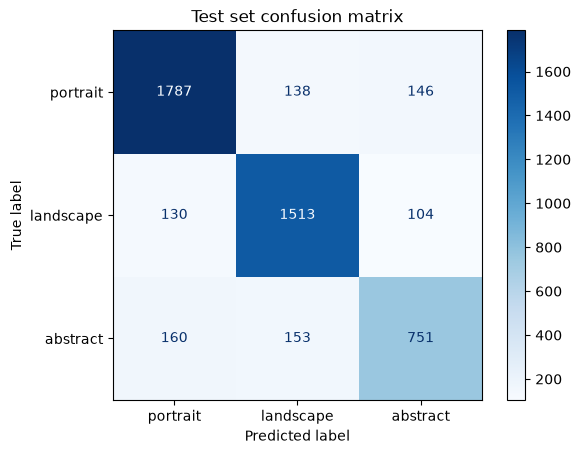

              precision    recall  f1-score   support

    portrait     0.8604    0.8629    0.8616      2071
   landscape     0.8387    0.8661    0.8522      1747
    abstract     0.7502    0.7058    0.7274      1064

    accuracy                         0.8298      4882
   macro avg     0.8164    0.8116    0.8137      4882
weighted avg     0.8286    0.8298    0.8290      4882



In [46]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

class_names = sorted(class_to_idx, key=class_to_idx.get)   # ['portrait', 'landscape', 'abstract']

best_lr, best_hidden_size, best_dropout = best_key
model = landscapeAbstractPortraitCNN(kernel_size=best_vals["kernel_size"],
                                     hidden_size=best_hidden_size, dropout=best_dropout).to(device)
model.load_state_dict(torch.load("best_problem4_cnn.pt", map_location=device))
model.eval()

predictions = []
with torch.no_grad():
    for inputs, _ in test_dataset:
        predictions.append(model(inputs.to(device)).argmax(dim=1).cpu())
y_pred = torch.cat(predictions).numpy() # Predicted labels for the test set
y_true = torch.cat([y for _, y in test_dataset]).numpy() # Ground truth labels for the test set

cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names).plot(cmap="Blues", values_format="d")
plt.title("Test set confusion matrix")
plt.show()
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))


class         TP    TN    FP    FN  (TP+TN)/N
portrait    1787  2521   290   284     0.8824
landscape   1513  2844   291   234     0.8925
abstract     751  3568   250   313     0.8847

Overall test accuracy: 0.8298  (4051 / 4882)


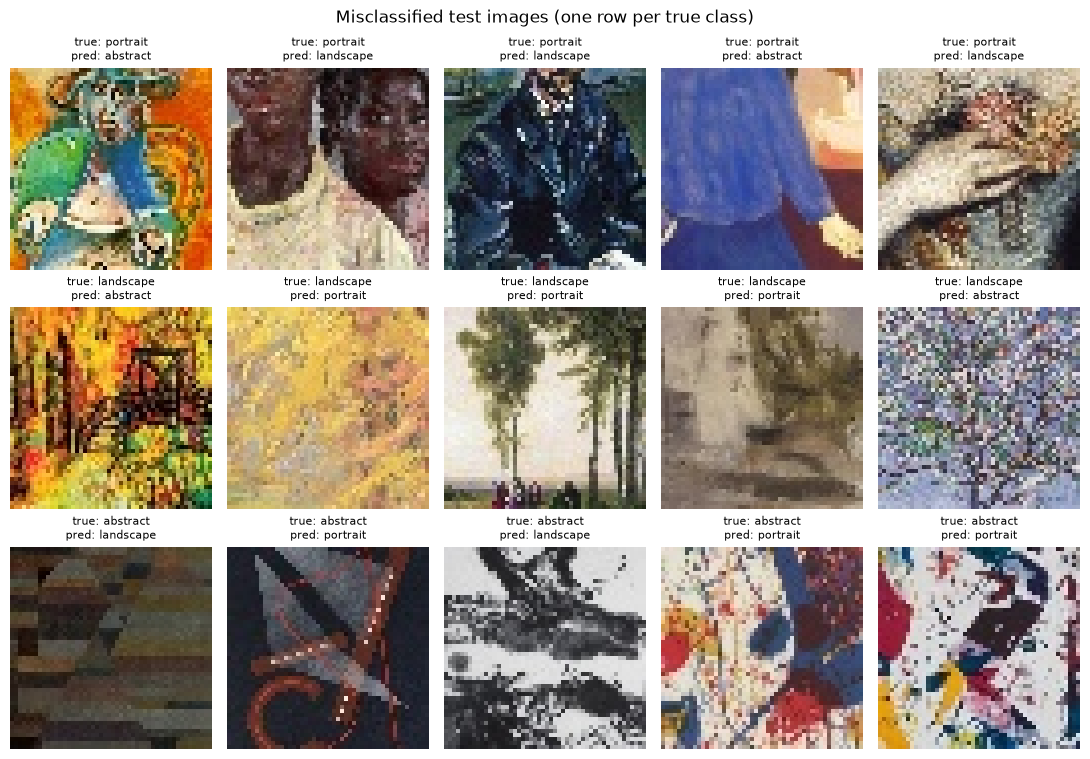

In [47]:
N = cm.sum()
print(f"{'class':<10} {'TP':>5} {'TN':>5} {'FP':>5} {'FN':>5}  {'(TP+TN)/N':>9}")
for i, name in enumerate(class_names):
    TP = cm[i, i]
    FN = cm[i, :].sum() - TP
    FP = cm[:, i].sum() - TP
    TN = N - TP - FP - FN
    print(f"{name:<10} {TP:>5} {TN:>5} {FP:>5} {FN:>5}  {(TP + TN) / N:>9.4f}")
print(f"\nOverall test accuracy: {np.trace(cm) / N:.4f}  ({np.trace(cm)} / {N})")


n_show = 5
fig, axes = plt.subplots(len(class_names), n_show, figsize=(2.2 * n_show, 2.6 * len(class_names)))
for c, name in enumerate(class_names):
    wrong = np.where((y_true == c) & (y_pred != c))[0][:n_show] # Indices of misclassified images for class c
    for j in range(n_show):
        ax = axes[c, j]
        ax.axis("off")
        if j < len(wrong):
            idx = wrong[j]
            ax.imshow(X_test[idx].permute(1, 2, 0).numpy())        # (3,50,50) -> (50,50,3)
            ax.set_title(f"true: {name}\npred: {class_names[y_pred[idx]]}", fontsize=8)
plt.suptitle("Misclassified test images (one row per true class)")
plt.tight_layout()
plt.show()

I noticed the pictures to be blurry and sometime difficult for myself to predict this is likley as a result of them being 50x50. 

## Problem 7 -- 10 points

### What characteristics of the CNN (beyond optimizing the hyperparameters) contributed to the presumably better performance than the feedforward network approach?

It is known that one major advantage of a CNN over a feed forward network is the number of parameters used and produces less overfitting.

One may assume that because the feed-forward network uses more parrameters, in the case of the assignment 12x more that is may produce better validation results. But as we see from this assignment the baseline CNN produced better validation accuracy 82% vs the accuracy of the FFN at ~62%.

One architectural difference to note is that the FFN flattens the image into separate numbers and has no idea which pixels are neighbors, while CNN keeps the 2D structure of images and studies neighbors using 3x3 kernels to find edges, colors, etc. 

Another reason for fewer parameters is that weight sharing (by moving the same filter across the image) means fewer parameters by default.  3.9M parameters vs 319K for CNN. 

Another reason why the CNN performs better than FFN is that the layered features to a lot of lifting. 
conv1 finds edges and colors, conv2 starts to combine them into shapes while conv3 structures them into larger images.

And lastly, CNN uses translation and pooling to help with pattern recognition. A face is a face regardless of what section of the image it is on, or if it is stretched out or thinned or flipped around. A feedforward network would need to learn all of these patterns newly.

## Problem 8  -- 5 points

### How long did this homework take?

20 hours

## Problem 9 -- 5 points

### Create a pdf of this notebook and submit the pdf file and this notebook.

### Up for a further challenge?  Try a transfer learning approach on this dataset.